<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Aggregating & Combining With pandas

---



## Learning objectives
---
In this lesson, we’ll use pandas to accomplish the following:

- Combine datasets in multiple ways:
    - Aggregate datasets using `groupby()`
    - Use `concat()` to UNION datasets together
    - Use `merge()` to JOIN datasets together
- Create insights from data by combining these methods!

## Import pandas
---
First things first, include your imports at the top of your notebook.

In [1]:
import pandas as pd



## Load the data
---



In [2]:
# load coffee_shop_cleaned.csv file
# while loading the data, set both transaction_date
# and customer_sice columns as date format using parse_dates option,
# or else use pd.to_datetime to convert them later to datetime format

coffee = pd.read_csv('./data/coffee_shop_cleaned.csv')
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday
3,2019-04-01,16:49:38,407,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.25,2.75,Monday
4,2019-04-01,19:17:34,537,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.50,5.50,Monday


## `unique()` and `nunique()`

The ```.unique()``` function is useful for showing the unique values in a column.


In [3]:
# unique() values in customer_generation column

coffee["customer_generation"].unique()

array(['Older Millennials', 'Baby Boomers', 'Gen Z', 'Gen X',
       'Younger Millennials'], dtype=object)

In [4]:
# nunique() values in customer_generation column
coffee["customer_generation"].nunique()


5


## Aggregating with groupby()
---
In pandas, `groupby()` statements allow us to segment our population to a specific subset and draw calculations based on those segment. A basic example looks like this:
`data_frame.groupby(['column_a']).count()`

We can think about a `groupby()` statement in three steps:
- Split: Separate our DataFrame into groups according to a specific attribute.
- Apply: Apply some function to the groups, like sum, count, or max.
- Combine: Put our DataFrame back together and check the output.

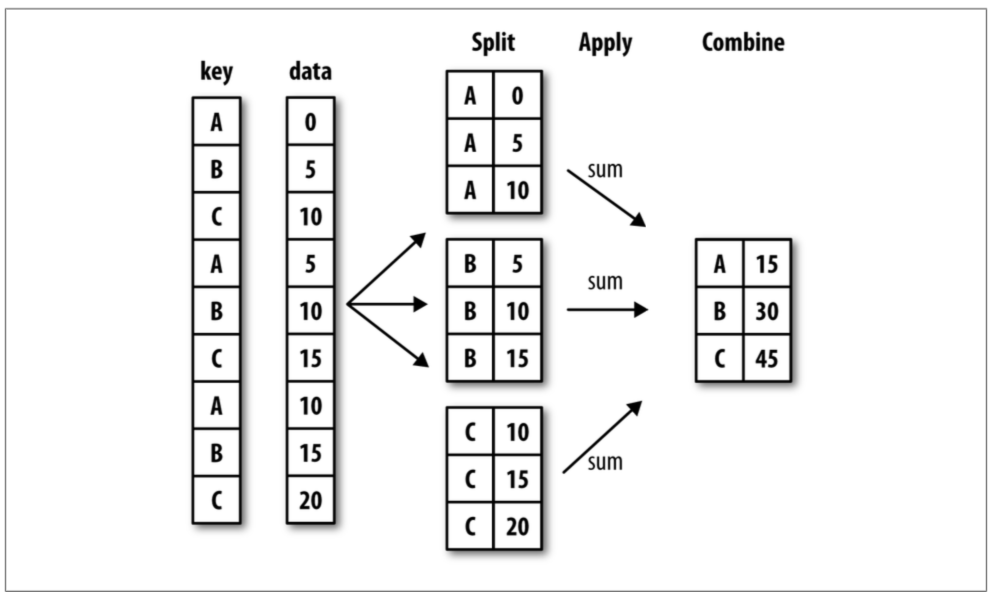


We can also groupby() multiple columns to drill down further:
`df.groupby(['first_column', 'second_column'])`


Let's run through a couple of examples of groupby using this dataset.



In [5]:
# let's check the value_counts of 'customer_generation'
coffee["customer_generation"].value_counts()


customer_generation
Baby Boomers           13208
Gen X                  12882
Older Millennials      10348
Gen Z                   7610
Younger Millennials     5785
Name: count, dtype: int64

In [6]:
# group by customer_generation then do count

coffee.groupby("customer_generation").count()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,vat,total,day
customer_generation,,,,,,,,,,,,,,,
Baby Boomers,13208,13208,13208,13208,13208,13208,13208,13208,13208,13208,6002,13208,13208,13208,13208
Gen X,12882,12882,12882,12882,12882,12882,12882,12882,12882,12882,5684,12882,12882,12882,12882
Gen Z,7610,7610,7610,7610,7610,7610,7610,7610,7610,7610,4277,7610,7610,7610,7610
Older Millennials,10348,10348,10348,10348,10348,10348,10348,10348,10348,10348,5462,10348,10348,10348,10348
Younger Millennials,5785,5785,5785,5785,5785,5785,5785,5785,5785,5785,3367,5785,5785,5785,5785


In [7]:
# group by customer_generation and take the mean of the unit_price column

coffee.groupby('customer_generation',dropna=False)[['unit_price']].mean()


,unit_price
customer_generation,
Baby Boomers,3.370453
Gen X,3.406640
Gen Z,3.352543
Older Millennials,3.406099
Younger Millennials,3.369258


> For Above code:
- `dropna=False` is an option to include null values in the group by result. 

- Since we modified null values from previous lecture to a value `unknown`, we don't need this option here. 

In [8]:
# do a groupby customer_generation then get the mean of quantity and unit_price

coffee.groupby("customer_generation")[["quantity","unit_price"]].mean()

,quantity,unit_price
customer_generation,,
Baby Boomers,1.436402,3.370453
Gen X,1.440615,3.406640
Gen Z,1.446912,3.352543
Older Millennials,1.436509,3.406099
Younger Millennials,1.433016,3.369258


- Groupby multiple columns

In [9]:
# do a groupby the two columns 'customer_generation' and 'product_type'
# then get the sum for the column 'quantity'

coffee.groupby(["customer_generation", "product_type"])[["quantity"]].sum()
pd.set_option('display.max_rows', None)  # run this code to display all the result



In [10]:
# get the mean for all numerical column after groupby 'customer_generation' 
coffee.groupby("customer_generation").mean(numeric_only=True)



,quantity,line_item_amount,unit_price,current_wholesale_price,customer_birth_year,vat,total
customer_generation,,,,,,,
Baby Boomers,1.436402,4.689699,3.370453,1.348495,1957.089643,0.470048,5.170528
Gen X,1.440615,4.738794,3.406640,1.372316,1971.922605,0.475031,5.225345
Gen Z,1.446912,4.647602,3.352543,1.326673,1997.768988,0.465547,5.121013
Older Millennials,1.436509,4.675267,3.406099,1.373098,1984.536529,0.468556,5.154120
Younger Millennials,1.433016,4.618921,3.369258,1.344854,1991.977874,0.463178,5.094960


> For Above code:
- `numeric_only=True` is an option to include the columns that are numericals to calculate the mean. If that option is not included then the code will give you error trying to calculate the mean for categorical columns.

In [11]:
# create a new dataframe called 'chai' for 'Brewed Chai tea' sales
chai = coffee[coffee["product_type"] == "Brewed Chai tea"]


In [12]:
# show the head of chai dataframe

chai.head(2)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday


In [13]:
# What generation buys the Brewed Chai tea sales the most?
# sort your result descending

chai.groupby("customer_generation")["quantity"].sum().sort_values(ascending=False)


customer_generation
Baby Boomers           2324
Gen X                  2215
Older Millennials      1833
Gen Z                  1336
Younger Millennials    1021
Name: quantity, dtype: int64

In [14]:
# What is the average total sales for Brewed Chai tea per generation?

chai.groupby("customer_generation")["total"].mean()


customer_generation
Baby Boomers           4.943853
Gen X                  4.889282
Gen Z                  4.918455
Older Millennials      4.989844
Younger Millennials    4.964513
Name: total, dtype: float64

Chaining commands like shown above can answer complex questions with just one line of code. It can be hard to read when you're just getting started learning Python, so don't be afraid to break it out across cells and see what your output looks like each step of the way! Take advantage of how easy it is to index DataFrames, Series, lists, and so on with our square brackets [ ].



### Taking Aggregate Measures with groupby

We can use the .agg() method to get multiple aggregate values:

`df.groupby('col_a')['col_b'].agg(['count', 'mean', 'sum', 'min', 'max'])`

The above command does the following:
- Takes our DataFrame, `df`
- Groups it by the values in `col_a` ("Split")
- Calculates the count, mean, minimum, and maximum of `col_b` ("Apply")
- And combines the results in a Series or DataFrame that's easy for us to digest ("Combine")

In [15]:
# show the sum for each product_group

coffee.groupby("product_group")["total"].sum()

product_group
Add-ons              3050.080
Beverages          198511.830
Food                30127.130
Merchandise          5031.400
Whole Bean/Teas     20664.875
Name: total, dtype: float64

In [39]:
# show the count, average, total, and highest total sales for each product_group

coffee.groupby("product_group")["total"].agg(["count", "mean", "sum", "max"])


,count,mean,sum,max
product_group,,,,
Add-ons,2248,1.356797,3050.080,3.52
Beverages,38617,5.140530,198511.830,18.70
Food,7584,3.972459,30127.130,9.90
Merchandise,245,20.536327,5031.400,79.20
Whole Bean/Teas,1139,18.142998,20664.875,396.00


### Aggregating Multiple Columns

``` python
result = df.groupby(['Year', 'Region']).agg({
    'Sales': 'sum',      
    'Profit': 'mean',    
    'ID': 'count'        
})
```
- Note: write square bracket in any of the aggragate to show the aggregate type for each column eq. ['sum']


In [40]:
# for each product_group, aggregate the sum of total and the sum of quantity

coffee.groupby("product_group").agg({

    "total": "sum",

    "quantity": "sum"

})

,total,quantity
product_group,,
Add-ons,3050.080,3466
Beverages,198511.830,59075
Food,30127.130,7732
Merchandise,5031.400,255
Whole Bean/Teas,20664.875,1168


## Aggregating date/time with `resample()`
---


> **`resample`** works just like a Group By, but it's specifically designed for dates and times
--- 
### How to use it (The 3-Step Formula):
    To make resampling work, you follow this pattern:
1. The Index: Your data **must have** a date/time column as its `index`.
2. The Rule: Tell it the new **frequency** (e.g., 'W' for weekly, 'D' for daily, 'h' for hourly). then tell it what to do with the numbers (e.g., .sum() or .mean())

Example : ```df.resample('W')['price'].mean()```

##### 1. The Index: Your data **must have** a date/time column as its `index`

In [18]:
# set the coffee dataframe index to be the transaction_date column
# for each product_group, aggregate the sum of total and the sum of quantity
coffee["transaction_date"] = pd.to_datetime(coffee["transaction_date"])


coffee = coffee.set_index("transaction_date")

# show the head
coffee.head()

,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
transaction_date,,,,,,,,,,,,,,,
2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday
2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday
2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday
2019-04-01,16:49:38,407,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.25,2.75,Monday
2019-04-01,19:17:34,537,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.50,5.50,Monday


##### 2. The Rule: Tell it the new **frequency** (e.g., 'W' for weekly, 'D' for daily,'h' for hourly) then specifiy the aggregate function to use

In [19]:
# for every 4 days aggregate the sum of total and the sum of quantity
coffee.resample("4D")[["total", "quantity"]].sum()


,total,quantity
transaction_date,,
2019-04-01,32206.680,9443
2019-04-05,33275.022,9420
2019-04-09,35281.928,9725
2019-04-13,37631.880,10218
2019-04-17,39233.403,10155
2019-04-21,37149.156,10396
2019-04-25,35520.606,10273
2019-04-29,7086.640,2066


### `groupby` a category then `resample` per date/time


In [20]:
# using group by category and then resample per date/time

coffee.groupby("product_category").resample("W")[["total", "quantity"]].sum()

total  quantity
product_category   transaction_date                     
Bakery             2019-04-07         6358.275      1632
                   2019-04-14         7997.165      2014
                   2019-04-21         7912.685      2039
                   2019-04-28         6847.445      1785
                   2019-05-05         1011.560       262
Branded            2019-04-14         1738.000        93
                   2019-04-21         2565.200       130
                   2019-04-28          728.200        32
Coffee             2019-04-07        24119.645      7251
                   2019-04-14        22964.920      6844
                   2019-04-21        23138.720      6946
                   2019-04-28        26575.505      8038
                   2019-05-05         3163.490       958
Coffee beans       2019-04-07          567.710        23
                   2019-04-14         4901.875       213
                   2019-04-21         7224.745       273
                   2019-04-28         2349.985       107
Drinking Chocolate 2019-04-07         6561.500      1435
                   2019-04-14         5980.700      1313
                   2019-04-21         6418.775      1401
                   2019-04-28         6853.275      1514
                   2019-05-05          850.025       183
Flavours           2019-04-07          105.600       120
                   2019-04-14         1214.400      1380
                   2019-04-21         1202.960      1367
                   2019-04-28          527.120       599
Loose Tea          2019-04-07          103.785        10
                   2019-04-14         1688.115       165
                   2019-04-21         1576.025       155
                   2019-04-28          722.645        71
Packaged Chocolate 2019-04-07           52.503         6
                   2019-04-14          707.729        70
                   2019-04-21          557.997        54
                   2019-04-28          211.761        21
Tea                2019-04-07        17943.365      5790
                   2019-04-14        16392.200      5296
                   2019-04-21        16865.255      5435
                   2019-04-28        18622.890      6008
                   2019-05-05         2061.565       663

### Common Resampling Rules
<table>
  <thead>
    <tr>
      <th style="text-align: left">Alias</th>
      <th style="text-align: left">Description</th>
      <th style="text-align: left">Use Case</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>D</strong></td>
      <td>Calendar day</td>
      <td>Standard daily tracking</td>
    </tr>
    <tr>
      <td><strong>B</strong></td>
      <td>Business day</td>
      <td>Excludes weekends/holidays</td>
    </tr>
    <tr>
      <td><strong>W</strong></td>
      <td>Weekly</td>
      <td>Weekly snapshots</td>
    </tr>
    <tr>
      <td><strong>ME</strong></td>
      <td>Month End</td>
      <td>Replaces deprecated 'M'</td>
    </tr>
    <tr>
      <td><strong>MS</strong></td>
      <td>Month Start</td>
      <td>Useful for budget tracking</td>
    </tr>
    <tr>
      <td><strong>QE</strong></td>
      <td>Quarter End</td>
      <td>Replaces deprecated 'Q'</td>
    </tr>
    <tr>
      <td><strong>YE</strong></td>
      <td>Year End</td>
      <td>Replaces deprecated 'A' or 'Y'</td>
    </tr>
    <tr>
      <td><strong>h</strong></td>
      <td>Hourly</td>
      <td>Sub-daily analysis</td>
    </tr>
    <tr>
      <td><strong>min</strong></td>
      <td>Minutely</td>
      <td>High-frequency data</td>
    </tr>
    <tr>
      <td><strong>s</strong></td>
      <td>Secondly</td>
      <td>Real-time monitoring</td>
    </tr>
  </tbody>
</table>


## Joining DataFrames
---


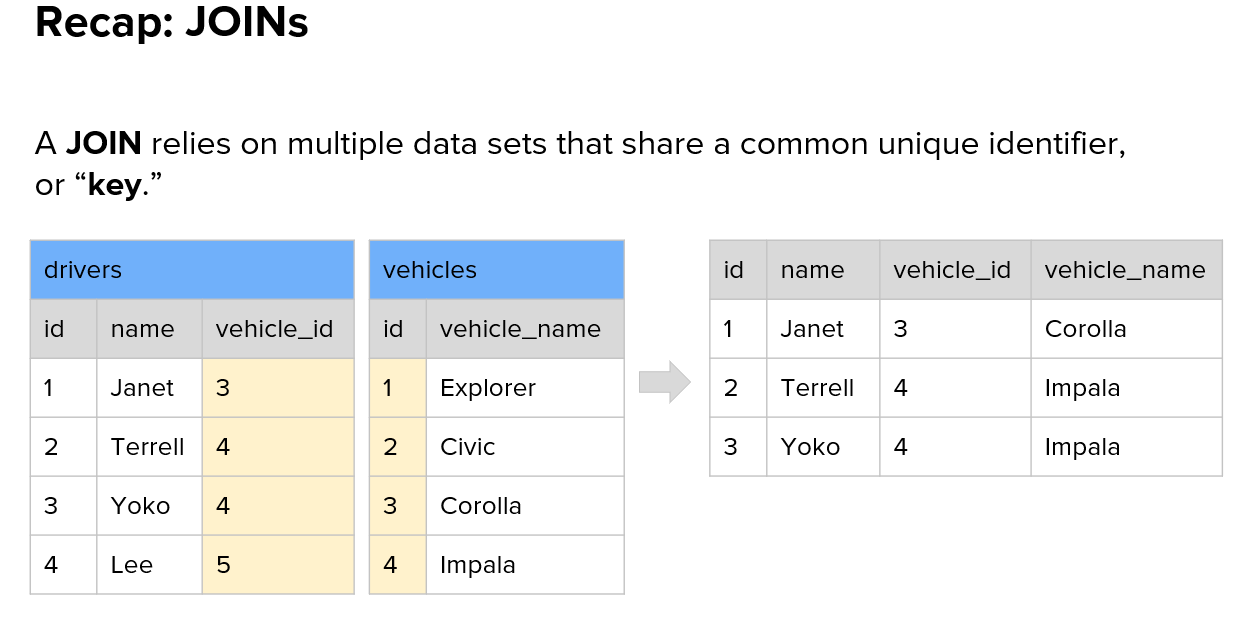

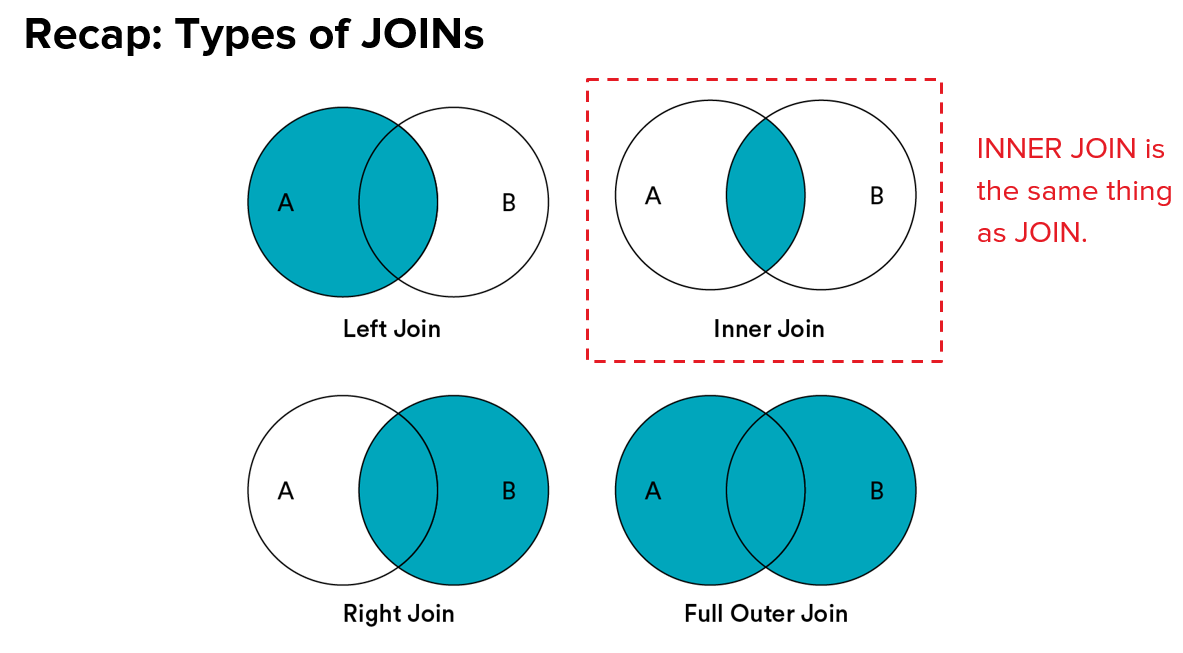

JOINing is the process of combining DataFrames according to specific values. Traditionally, this would be done with SQL - we already know how to do this!

JOINing allows us to:
- Reduce the size of a database.
- Increase the speed at which data is queried and returned.
- Reduce the redundancy of the data stored in the database.
- Access data that is split across multiple tables
  

JOIN is used to combine tables for the purpose of adding selection criteria and possibly additional columns.
- They connect data sources together in order to use information from both tables to display a desired result.
- A JOIN allows for tables to be connected using common columns, which serve as unique identifiers (called KEYS).
- Note that unique identifiers aren’t required, but are almost always used to avoid unintended behavior.

The robust method for JOINing in pandas is `merge()`, which accepts several parameters:

`pd.merge(left_df, right_df, how, on, left_on, right_on)`

As you may have guessed:
- the first two parameters are the DataFrames to JOIN.
- The third parameter `how` describes the type of JOIN, typically "left", default is 'inner'
- the fourth parameter `on` if both keys from the two tables has a common name. if you use this option, you can ignore the last two parameters
-  The last two parameters provide the column name for the shared column, or foreign key, that will be used to combine the two DataFrames.

#### Loading Data

In [21]:
age      = pd.read_csv("./data/age.csv")
color    = pd.read_csv("./data/color.csv")
location = pd.read_csv("./data/location.csv")

In [22]:
age

,Unique Squirrel ID,Age
0,8A-AM-1013-06,Juvenile
1,7H-PM-1006-07,Adult
2,3G-PM-1013-03,Adult
3,22F-AM-1007-07,Juvenile
4,20A-PM-1017-01,Adult


In [23]:
color

,Unique Squirrel ID,Primary Fur Color
0,20A-PM-1017-01,Gray
1,22F-AM-1007-07,Cinnamon
2,7H-PM-1006-07,Gray
3,3G-PM-1013-03,Gray


In [24]:
location

,unique_squirrel_id,lat,long
0,3G-PM-1013-03,-73.974437,40.767428
1,7H-PM-1006-07,-73.970026,40.769934
2,31F-AM-1013-01,-73.959687,40.789379
3,8A-AM-1013-06,-73.977310,40.773805
4,22F-AM-1007-07,-73.964660,40.782770
5,20A-PM-1017-01,-73.970069,40.782889


#### merge()

When we use .merge():

- Only merges 2 dataframes
- We MUST merge on a common column - this is information that is shared by both dataframes.

What is the common column in the age and color dataframes?



In [25]:
# inner join on age and color

pd.merge(left = age,
         right = color,
         how = "inner",
         on = "Unique Squirrel ID")

,Unique Squirrel ID,Age,Primary Fur Color
0,7H-PM-1006-07,Adult,Gray
1,3G-PM-1013-03,Adult,Gray
2,22F-AM-1007-07,Juvenile,Cinnamon
3,20A-PM-1017-01,Adult,Gray


What if we don't want the intersection and, instead, we want to keep everything from the left table (i.e. age, the bigger one)?


In [26]:
# left join on age and color
pd.merge(left = age,
         right = color,
         how = "left",
         on = "Unique Squirrel ID")

,Unique Squirrel ID,Age,Primary Fur Color
0,8A-AM-1013-06,Juvenile,NaN
1,7H-PM-1006-07,Adult,Gray
2,3G-PM-1013-03,Adult,Gray
3,22F-AM-1007-07,Juvenile,Cinnamon
4,20A-PM-1017-01,Adult,Gray


What if we have a dataframe with a different name for the column we wish to join "on"?


In [27]:
# what are the columns of age dataset
age.columns 

Index(['Unique Squirrel ID', 'Age'], dtype='object')

In [28]:
# what are the columns of location dataset

location.columns

Index(['unique_squirrel_id', 'lat', 'long'], dtype='object')

In [29]:
# try to join using 'on'
# This breaks...it gives error.
pd.merge(left = age,
         right = location,
         on = "Unique Squirrel ID")

KeyError: 'Unique Squirrel ID'

In [30]:
# This WORKS! we use 'left_on' and 'right_on'
pd.merge(left = age,
         right = location,
         left_on = "Unique Squirrel ID",
         right_on = "unique_squirrel_id")

,Unique Squirrel ID,Age,unique_squirrel_id,lat,long
0,8A-AM-1013-06,Juvenile,8A-AM-1013-06,-73.977310,40.773805
1,7H-PM-1006-07,Adult,7H-PM-1006-07,-73.970026,40.769934
2,3G-PM-1013-03,Adult,3G-PM-1013-03,-73.974437,40.767428
3,22F-AM-1007-07,Juvenile,22F-AM-1007-07,-73.964660,40.782770
4,20A-PM-1017-01,Adult,20A-PM-1017-01,-73.970069,40.782889


### Concatinating DataFrames `pd.concat()`
---

We can combine or concatenate two DataFrames together with the `pd.concat()` method. This gives us the option to stack the DataFrames vertically to add more rows, or add the DataFrames side by side as new columns.

**Note:** There are a lot of parameters that can be used to control how datasets are unioned using `pd.concat()`, including whether you allow duplicate entries and whether you're concatenating axes that are not shared between the DataFrames. Be sure to read the documentation if you want to use this method!

- Concatenating by rows


In [31]:
# Creating a new DataFrame with single row
new_color = pd.DataFrame(data = [['8A-AM-1013-06', "Orange"]],
                             columns = ['Unique Squirrel ID', 'Primary Fur Color'])

In [32]:
# show the newly created Dataframe
new_color


,Unique Squirrel ID,Primary Fur Color
0,8A-AM-1013-06,Orange


In [33]:
# Concatenate new datapoint to existing dataframe
all_color = pd.concat([color, new_color])
all_color

,Unique Squirrel ID,Primary Fur Color
0,20A-PM-1017-01,Gray
1,22F-AM-1007-07,Cinnamon
2,7H-PM-1006-07,Gray
3,3G-PM-1013-03,Gray
0,8A-AM-1013-06,Orange


Is there anything odd about this new dataframe?



In [34]:
# reset the index 
all_color.reset_index(drop=True, inplace = True)
all_color

,Unique Squirrel ID,Primary Fur Color
0,20A-PM-1017-01,Gray
1,22F-AM-1007-07,Cinnamon
2,7H-PM-1006-07,Gray
3,3G-PM-1013-03,Gray
4,8A-AM-1013-06,Orange


**Note**:

It's a good idea to familiarize yourself with each dataset BEFORE merging and joining them. This lets you identify any red flags and remove unneccessary, erroneous, or null-riddled rows and columns to cut down on the total amount of data you're handling. Adding calculated fields and replacing values or filling nulls is also faster when you're applying those methods to smaller datasets, so starting with those steps could save you some processing time if different files require different cleaning steps.

## Lesson Summary
---
Today, we:


- Used groupby() and JOIN statements to combine data with pandas.
- Created insights from data by splitting and combining data segments.


In [38]:
# %autosave 0